### ============================================================================
### MULTIMODAL LATE FUSION (FEATURE-LEVEL) FOR BRAIN TUMOR DETECTION
### ============================================================================
### Author: Jeisson Parra Prieto 
### Description:
####   - Loads pre-trained MRI (two-stage) and CT (correlation) models.
####  - Extracts features from the penultimate layer of each model.
####   - Concatenates features and trains a fusion classifier on paired data.
####   - Evaluates performance against unimodal baselines.
####   - Generates Grad-CAM heatmaps for interpretability.
### ============================================================================


In [44]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
from math import pi
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import cv2
import matplotlib.cm as cm

🧠 MULTIMODAL LATE FUSION (FEATURE-LEVEL) PIPELINE
[1/6] Loading pre-trained models...
  - MRI stage-1 loaded.
  - MRI stage-2 loaded.
  - Reconstructing CT model architecture...
  - CT model weights loaded successfully (by name).

[Verification] CT model architecture after weight loading:


/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CT_Correlation_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ct_input            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, 8, 8,      │          0 │ ct_input[0][0]    │
│ (Lambda)            │ 3136)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_flat        │ (None, 64, 3136)  │          0 │ patch_extractor[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_image       │ (None, 64, 28,    │          0 │ reshape_flat[0][… │
│ (Reshape)           │ 28, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_e… │ (None, 64, 128)   │    421,472 │ reshape_image[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correlation_layer   │ (None, 64, 64)    │          0 │ time_distributed… │
│ (CorrelationLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ guided_features     │ (None, 64, 128)   │          0 │ correlation_laye… │
│ (Dot)               │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 64, 256)   │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ guided_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 256)       │          0 │ combined_feature… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │     65,792 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 256)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 32)        │      8,224 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │         66 │ fc2[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 495,554 (1.89 MB)

...

 Trainable params: 45,378 (177.26 KB)

 Non-trainable params: 2,237,152 (8.53 MB)

[2/6] Preparing unpaired multimodal generators...
[Generator] Created 14514 pseudo-pairs for split 'train'
[Generator] Created 3112 pseudo-pairs for split 'val'
[Generator] Created 3113 pseudo-pairs for split 'test'
[3/6] Training fusion model with pseudo-pairing...
Epoch 1/3


/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2419/2419 ━━━━━━━━━━━━━━━━━━━━ 49s 19ms/step - accuracy: 0.8906 - loss: 0.7648 - val_accuracy: 0.9438 - val_loss: 0.2789 - learning_rate: 1.0000e-04
Epoch 2/3
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9246 - loss: 0.3196 - val_accuracy: 0.9473 - val_loss: 0.1574 - learning_rate: 1.0000e-04
Epoch 3/3
2419/2419 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9286 - loss: 0.2421 - val_accuracy: 0.9454 - val_loss: 0.1341 - learning_rate: 1.0000e-04


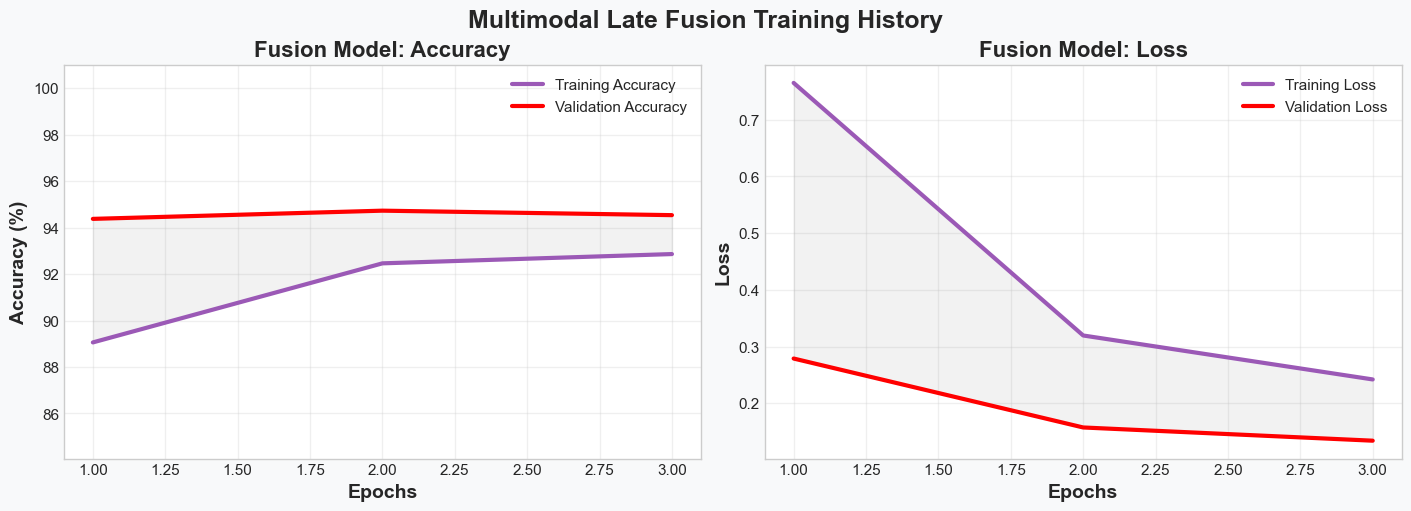

[4/6] Evaluating fusion model on test set...


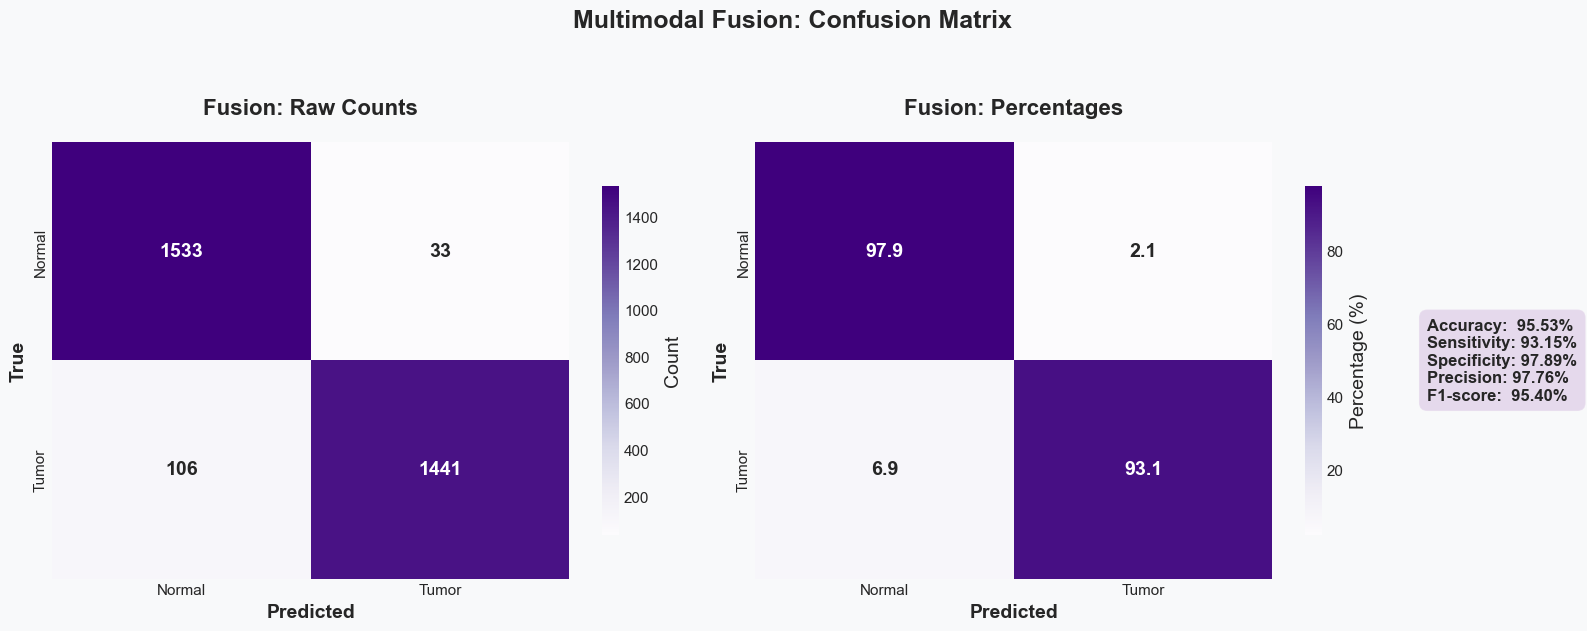

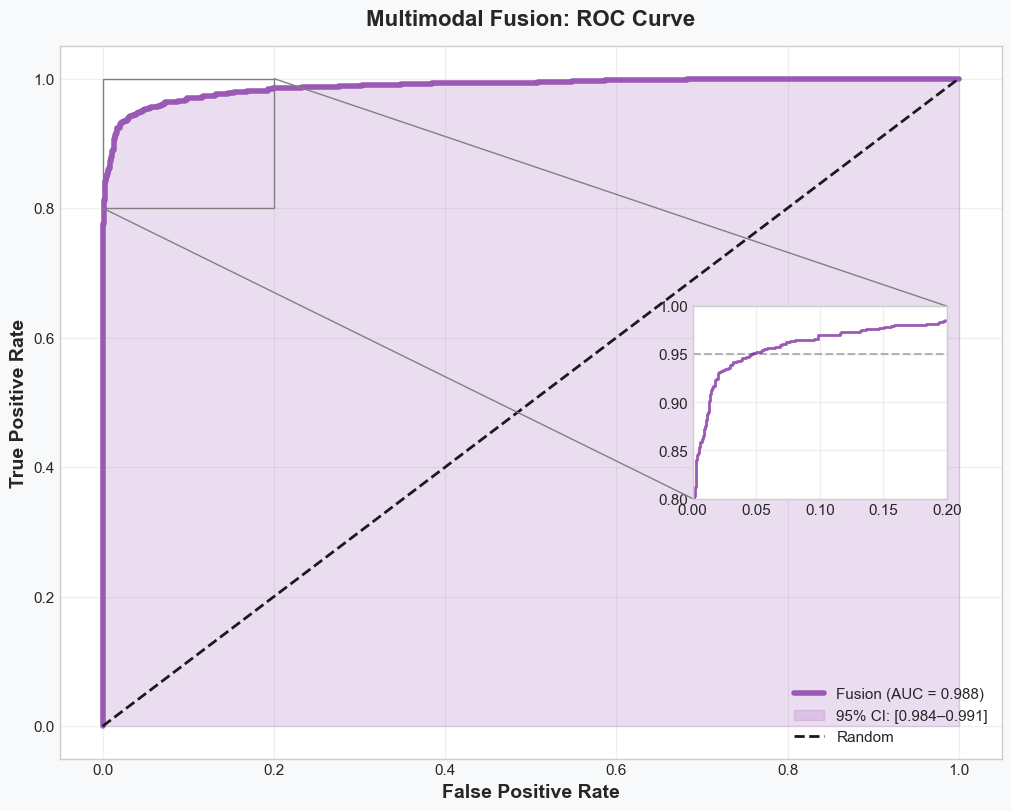

[5/6] Loading unimodal baseline scores...
MRI scores: [93.80019274012207, 97.94617563739378, 89.39883645766, 93.47752619128083, 98.52286921252438]
CT scores: [74.81529071635079, 74.78882391163093, 74.40206851971558, 74.59494491250811, 80.79816659938365]
Fusion scores: [95.53485383874076, 97.76119402985076, 93.14802844214609, 95.3988745448527, 98.76521194979614]


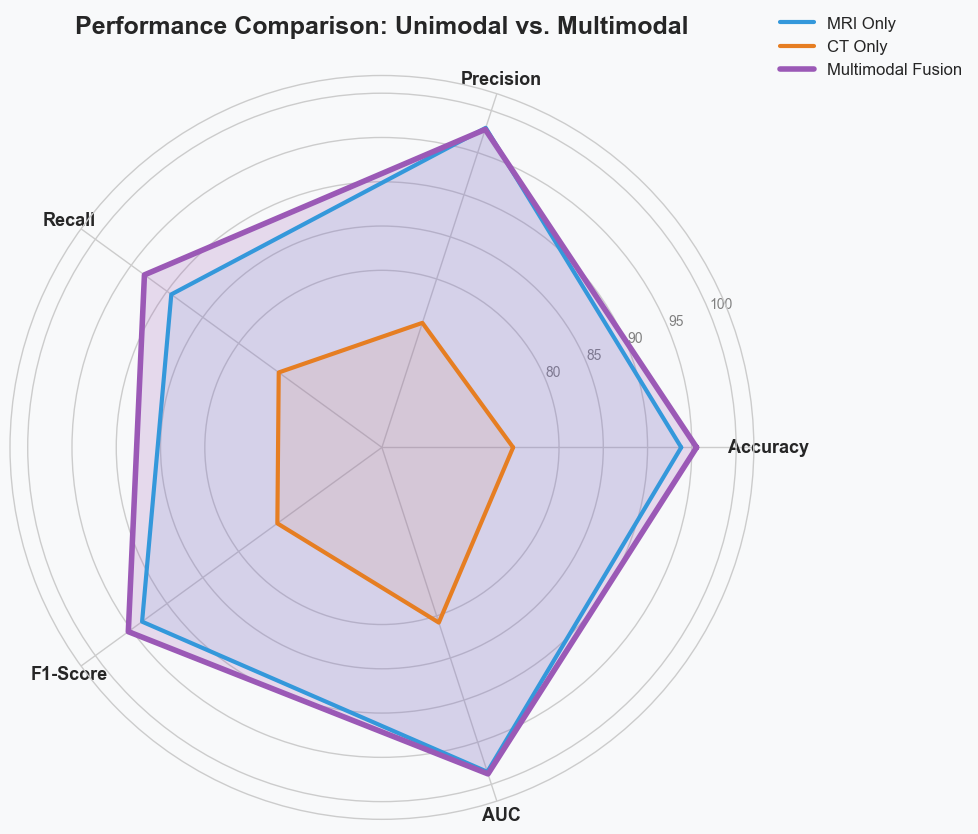


CLASSIFICATION REPORT - FUSION MODEL
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96      1566
       Tumor       0.98      0.93      0.95      1547

    accuracy                           0.96      3113
   macro avg       0.96      0.96      0.96      3113
weighted avg       0.96      0.96      0.96      3113


 MULTIMODAL FUSION PIPELINE COMPLETED
All figures saved to: ./Results/Fusion_figures


In [45]:
# ============================================================================
# MULTIMODAL LATE FUSION (FEATURE-LEVEL) FOR BRAIN TUMOR DETECTION
# ============================================================================
# This script reconstructs the CT model from code (to avoid Lambda serialisation issues)
# and loads its pre‑trained weights. It then builds a fusion model on top of
# features from MRI stage‑1 and CT models.
# ============================================================================

import os
import re
import pickle
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from math import pi
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import cv2

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    # Paths to pre-trained models
    'MRI_STAGE1_PATH': './Saved_models/MRI_stage1_binary_model.keras',
    'MRI_STAGE2_PATH': './Saved_models/MRI_stage2_multiclass_model.keras',
    'CT_MODEL_PATH': './Saved_models/ct_correlation_model.keras',   # weights file (old version)

    # Data directories (must contain train/val/test subfolders with MRI and CT)
    'MRI_DATA_ROOT': '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/MRI',
    'CT_DATA_ROOT': '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/CT',

    # Fusion model parameters
    'FUSION_INPUT_SHAPE_MRI': (128, 128, 4),
    'FUSION_INPUT_SHAPE_CT': (224, 224, 4),
    'NUM_CLASSES': 2,                # binary: normal vs tumor
    'BATCH_SIZE': 6,
    'EPOCHS': 3,
    'LEARNING_RATE': 1e-4,

    # Output paths
    'FUSION_MODEL_SAVE_PATH': './Saved_models/fusion_model.keras',
    'FIGURE_PATH': './Results/Fusion_figures',
    'RESULTS_PATH': './Results',
}

CLASS_NAMES = ['Normal', 'Tumor']
STAGE2_CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitary']

COLORS = {
    'mri': '#3498DB',
    'ct': '#E67E22',
    'multimodal': '#9B59B6',
    'normal': '#2ECC71',
    'tumor': '#E74C3C',
    'background': '#F8F9FA',
    'meningioma': '#3498DB',
    'glioma': '#9B59B6',
    'pituitary': '#E67E22',
}

os.makedirs(CONFIG['FIGURE_PATH'], exist_ok=True)
os.makedirs(CONFIG['RESULTS_PATH'], exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# ============================================================================
# CT MODEL ARCHITECTURE
# ============================================================================

class CorrelationLayer(layers.Layer):
    def call(self, inputs):
        return tf.matmul(inputs, inputs, transpose_b=True)

def build_ct_correlation_model(input_shape, patch_size, num_patches, num_classes):
    inputs = layers.Input(shape=input_shape, name="ct_input")

    # Patch extraction (with explicit output_shape for safety)
    extract_patches = layers.Lambda(
        lambda x: tf.image.extract_patches(
            images=x,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        ),
        output_shape=lambda s: (s[0], 
                                input_shape[0] // patch_size, 
                                input_shape[1] // patch_size, 
                                patch_size * patch_size * input_shape[2]),
        name="patch_extractor"
    )
    patches = extract_patches(inputs)                     # (batch, 8, 8, 28*28*4)

    patches_reshaped = layers.Reshape((num_patches, -1), name="reshape_flat")(patches)  # (batch, 64, 3136)
    patches_img = layers.Reshape((num_patches, patch_size, patch_size, input_shape[-1]), 
                                  name="reshape_image")(patches_reshaped)

    # Shared CNN encoder with explicit names
    encoder = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(patch_size, patch_size, input_shape[-1]),
                      name="enc_conv1"),
        layers.MaxPooling2D((2, 2), name="enc_pool1"),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="enc_conv2"),
        layers.MaxPooling2D((2, 2), name="enc_pool2"),
        layers.Flatten(name="enc_flatten"),
        layers.Dense(128, activation='relu', name="enc_dense"),
        layers.LayerNormalization(name="enc_layernorm")
    ], name="shared_encoder")

    patch_features = layers.TimeDistributed(encoder, name="time_distributed_encoder")(patches_img)  # (batch, 64, 128)

    correlation_matrix = CorrelationLayer(name="correlation_layer")(patch_features)  # (batch, 64, 64)

    guided_features = layers.Dot(axes=(2, 1), name="guided_features")([correlation_matrix, patch_features])

    combined_features = layers.Concatenate(axis=-1, name="combined_features")([patch_features, guided_features])

    pooled_features = layers.GlobalAveragePooling1D(name="global_pool")(combined_features)  # (batch, 256)

    # Classification head (with explicit names)
    x = layers.Dense(256, activation='relu', name="fc1")(pooled_features)
    x = layers.Dropout(0.5, name="dropout1")(x)
    x = layers.Dense(32, activation='relu', name="fc2")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CT_Correlation_Model")
    return model

# ============================================================================
# UNPAIRED DATA GENERATOR (Class-Based Pairing)
# ============================================================================

class UnpairedMultimodalGenerator(tf.keras.utils.Sequence):
    """
    Generates batches of (MRI, CT) pairs by matching samples from the SAME CLASS
    instead of the SAME PATIENT.
    """
    def __init__(self, mri_root, ct_root, split='train', batch_size=16,
                 mri_shape=(128,128,4), ct_shape=(224,224,4), shuffle=True):
        self.mri_root = os.path.join(mri_root, split)
        self.ct_root = os.path.join(ct_root, split)
        self.split = split
        self.batch_size = batch_size
        self.mri_shape = mri_shape
        self.ct_shape = ct_shape
        self.shuffle = shuffle
        self.pairs = [] 
        self._build_pseudo_pairs()
        self.on_epoch_end()

    def _get_files_by_class(self, root_dir):
        """Organizes files into a dictionary: {0: [paths], 1: [paths]}"""
        class_map = {0: [], 1: []}
        for root, _, files in os.walk(root_dir):
            for f in files:
                if f.endswith('.npy'):
                    path = os.path.join(root, f)
                    # Label 0 for Normal, 1 for Tumor
                    label = 0 if 'normal' in path.lower() or 'normal' in f.lower() else 1
                    class_map[label].append(path)
        return class_map

    def _build_pseudo_pairs(self):
        """Pairs MRI and CT files based on class labels."""
        mri_classes = self._get_files_by_class(self.mri_root)
        ct_classes = self._get_files_by_class(self.ct_root)

        for label in [0, 1]:
            mri_list = mri_classes[label]
            ct_list = ct_classes[label]
            
            if not mri_list or not ct_list:
                print(f"[Warning] Missing data for class {label} in {self.split} split.")
                continue

            # Shuffle to ensure random pairing
            random.shuffle(mri_list)
            random.shuffle(ct_list)

            # Match them 1-to-1 up to the smaller list size
            num_pairs = max(len(mri_list), len(ct_list))
            
            for i in range(num_pairs):
                mri_path = mri_list[i % len(mri_list)]
                ct_path = ct_list[i % len(ct_list)]
                self.pairs.append((mri_path, ct_path, label))

        if len(self.pairs) == 0:
            raise RuntimeError(f"No files found for split '{self.split}'.")
        
        print(f"[Generator] Created {len(self.pairs)} pseudo-pairs for split '{self.split}'")

    def __len__(self):
        return int(np.ceil(len(self.pairs) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.pairs))
        batch_indices = self.indexes[start:end]
        batch_pairs = [self.pairs[i] for i in batch_indices]

        mri_batch = np.zeros((len(batch_pairs), *self.mri_shape), dtype=np.float32)
        ct_batch = np.zeros((len(batch_pairs), *self.ct_shape), dtype=np.float32)
        labels = []

        for i, (mri_path, ct_path, label) in enumerate(batch_pairs):
            mri_img = np.load(mri_path).astype(np.float32)
            ct_img = np.load(ct_path).astype(np.float32)

            # Resize if necessary
            if mri_img.shape[:2] != self.mri_shape[:2]:
                mri_img = tf.image.resize(mri_img, self.mri_shape[:2]).numpy()
            if ct_img.shape[:2] != self.ct_shape[:2]:
                ct_img = tf.image.resize(ct_img, self.ct_shape[:2]).numpy()

            mri_batch[i] = mri_img
            ct_batch[i] = ct_img
            labels.append(label)

        return (mri_batch, ct_batch), to_categorical(labels, num_classes=2)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.pairs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

# ============================================================================
# LOAD PRE-TRAINED MODELS AND CREATE FEATURE EXTRACTORS
# ============================================================================

def load_pretrained_models():
    """Load MRI stage-1, stage-2, and reconstruct CT model with weights."""
    print("[1/6] Loading pre-trained models...")

    # MRI models (standard Keras – load normally)
    mri_stage1 = tf.keras.models.load_model(CONFIG['MRI_STAGE1_PATH'])
    print("  - MRI stage-1 loaded.")

    mri_stage2 = tf.keras.models.load_model(CONFIG['MRI_STAGE2_PATH'])
    print("  - MRI stage-2 loaded.")

    # CT model: reconstruct and load weights by name
    print("  - Reconstructing CT model architecture...")
    ct_model = build_ct_correlation_model(
        input_shape=CONFIG['FUSION_INPUT_SHAPE_CT'],
        patch_size=28,          # must match training
        num_patches=64,
        num_classes=2
    )

    # Load weights using by_name=True (layer names must match)
    ct_model.load_weights(CONFIG['CT_MODEL_PATH'])
    print("  - CT model weights loaded successfully (by name).")

    print("\n[Verification] CT model architecture after weight loading:")
    ct_model.summary()
    print(f"  - Total parameters in CT model: {ct_model.count_params():,}")

    return mri_stage1, mri_stage2, ct_model

def create_feature_extractors(mri_stage1, ct_model):
    """
    Create models that output features from the penultimate layer.
    For MRI stage-1: layer 'fc3' (Dense(256)).
    For CT model: penultimate Dense layer (index -2, Dense(32)).
    """
    mri_feature = models.Model(
        inputs=mri_stage1.input,
        outputs=mri_stage1.get_layer('fc3').output,
        name="MRI_feature_extractor"
    )
    mri_feature.trainable = False
    print("  - MRI feature extractor created (output shape: 256).")

    ct_feature = models.Model(
        inputs=ct_model.input,
        outputs=ct_model.layers[-2].output,   # penultimate layer (Dense(32))
        name="CT_feature_extractor"
    )
    ct_feature.trainable = False
    print("  - CT feature extractor created (output shape: 32).")

    return mri_feature, ct_feature

# ============================================================================
# BUILD FUSION MODEL
# ============================================================================

def build_fusion_model(mri_feature, ct_feature):
    """Concatenate features and add dense layers for binary classification."""
    mri_input = layers.Input(shape=CONFIG['FUSION_INPUT_SHAPE_MRI'], name="MRI_input")
    ct_input = layers.Input(shape=CONFIG['FUSION_INPUT_SHAPE_CT'], name="CT_input")

    mri_feat = mri_feature(mri_input)      # (256,)
    ct_feat = ct_feature(ct_input)          # (32,)

    concat = layers.Concatenate(name="concat_features")([mri_feat, ct_feat])  # (288,)

    x = layers.Dense(128, activation='relu', name="fc_joint_1")(concat)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu', name="fc_joint_2")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(2, activation='softmax', name="output")(x)

    model = models.Model(inputs=[mri_input, ct_input], outputs=output, name="Multimodal_Fusion")
    return model

# ============================================================================
# TRAINING AND EVALUATION UTILITIES
# ============================================================================

def plot_fusion_training_curves(history):
    acc = np.array(history.history['accuracy']) * 100
    val_acc = np.array(history.history['val_accuracy']) * 100
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(acc)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])

    ax1.plot(epochs, acc, color=COLORS['multimodal'], label='Training Accuracy', lw=3)
    ax1.plot(epochs, val_acc, color='red', label='Validation Accuracy', lw=3)
    ax1.fill_between(epochs, acc, val_acc, alpha=0.1, color='gray')
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontweight='bold')
    ax1.set_title('Fusion Model: Accuracy', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim([min(acc.min(), val_acc.min())-5, 101])

    ax2.plot(epochs, loss, color=COLORS['multimodal'], label='Training Loss', lw=3)
    ax2.plot(epochs, val_loss, color='red', label='Validation Loss', lw=3)
    ax2.fill_between(epochs, loss, val_loss, alpha=0.1, color='gray')
    ax2.set_xlabel('Epochs', fontweight='bold')
    ax2.set_ylabel('Loss', fontweight='bold')
    ax2.set_title('Fusion Model: Loss', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.suptitle('Multimodal Late Fusion Training History', fontsize=18, fontweight='bold')
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'fusion_training_curves.png'), dpi=300)
    plt.show()

def plot_fusion_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(COLORS['background'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax1,
                cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    ax1.set_xlabel('Predicted', fontweight='bold')
    ax1.set_ylabel('True', fontweight='bold')
    ax1.set_title('Fusion: Raw Counts', fontweight='bold', pad=20)

    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax2,
                cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    ax2.set_xlabel('Predicted', fontweight='bold')
    ax2.set_ylabel('True', fontweight='bold')
    ax2.set_title('Fusion: Percentages', fontweight='bold', pad=20)

    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/np.sum(cm)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1 = 2*(prec*sens)/(prec+sens) if (prec+sens)>0 else 0

    textstr = (f'Accuracy:  {acc*100:.2f}%\n'
               f'Sensitivity: {sens*100:.2f}%\n'
               f'Specificity: {spec*100:.2f}%\n'
               f'Precision: {prec*100:.2f}%\n'
               f'F1-score:  {f1*100:.2f}%')
    ax2.text(1.3, 0.5, textstr, transform=ax2.transAxes,
             fontsize=12, fontweight='bold', verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.5", facecolor=COLORS['multimodal'], alpha=0.2))

    plt.suptitle('Multimodal Fusion: Confusion Matrix', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'fusion_confusion_matrix.png'), dpi=300)
    plt.show()
    return acc, sens, spec, prec, f1

def plot_fusion_roc_curve(y_true, y_pred_proba):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
    base_auc = auc(fpr, tpr)

    rng = np.random.RandomState(42)
    n_bootstraps = 1000
    bootstrapped_aucs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true_arr), len(y_true_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = roc_auc_score(y_true_arr[indices], y_pred_proba[indices, 1])
        bootstrapped_aucs.append(score)
    ci_lower = np.percentile(bootstrapped_aucs, 2.5)
    ci_upper = np.percentile(bootstrapped_aucs, 97.5)

    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])

    ax.plot(fpr, tpr, color=COLORS['multimodal'], lw=4,
            label=f'Fusion (AUC = {base_auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.2, color=COLORS['multimodal'],
                    label=f'95% CI: [{ci_lower:.3f}–{ci_upper:.3f}]')
    ax.plot([0,1], [0,1], 'k--', lw=2, label='Random')
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title('Multimodal Fusion: ROC Curve', fontweight='bold', pad=15)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    axins = inset_axes(ax, width="30%", height="30%", loc='center right',
                       bbox_to_anchor=(0.05,0.05,0.9,0.9), bbox_transform=ax.transAxes)
    mask = fpr <= 0.2
    axins.plot(fpr[mask], tpr[mask], color=COLORS['multimodal'], lw=2)
    axins.plot([0,0.2], [0.95,0.95], 'k--', alpha=0.3)
    axins.set_xlim([0,0.2]); axins.set_ylim([0.8,1.0])
    axins.grid(True, alpha=0.3)
    mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="gray")

    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'fusion_roc_curve.png'), dpi=300)
    plt.show()
    return base_auc, ci_lower, ci_upper

def plot_radar_chart(mri_scores, ct_scores, fusion_scores):
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(COLORS['background'])
    ax.set_facecolor(COLORS['background'])

    mri_vals = mri_scores + mri_scores[:1]
    ct_vals = ct_scores + ct_scores[:1]
    fusion_vals = fusion_scores + fusion_scores[:1]

    ax.plot(angles, mri_vals, linewidth=3, color=COLORS['mri'], label='MRI Only')
    ax.fill(angles, mri_vals, color=COLORS['mri'], alpha=0.1)
    ax.plot(angles, ct_vals, linewidth=3, color=COLORS['ct'], label='CT Only')
    ax.fill(angles, ct_vals, color=COLORS['ct'], alpha=0.1)
    ax.plot(angles, fusion_vals, linewidth=4, color=COLORS['multimodal'], label='Multimodal Fusion')
    ax.fill(angles, fusion_vals, color=COLORS['multimodal'], alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=13, fontweight='bold')
    ax.set_ylim(60, 102)
    ax.set_yticks([80,85,90,95,100])
    ax.set_yticklabels(['80','85','90','95','100'], color='grey', size=10)
    ax.set_title('Performance Comparison: Unimodal vs. Multimodal', size=18, fontweight='bold', pad=30)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'radar_chart.png'), dpi=300)
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'radar_chart.pdf'))
    plt.show()


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_fusion_pipeline():
    print("="*70)
    print("🧠 MULTIMODAL LATE FUSION (FEATURE-LEVEL) PIPELINE")
    print("="*70)

    # 1. Load pre-trained models
    mri_stage1, mri_stage2, ct_model = load_pretrained_models()

    # 2. Create feature extractors
    mri_feature, ct_feature = create_feature_extractors(mri_stage1, ct_model)

    # 3. Build fusion model
    fusion_model = build_fusion_model(mri_feature, ct_feature)
    fusion_model.compile(
        optimizer=optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    fusion_model.summary()

    # 4. Prepare unpaired data generators (Modified logic)
    print("[2/6] Preparing unpaired multimodal generators...")
    train_gen = UnpairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'], CONFIG['CT_DATA_ROOT'], split='train', batch_size=CONFIG['BATCH_SIZE'], mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'], ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'])
    val_gen = UnpairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'], CONFIG['CT_DATA_ROOT'], split='val', batch_size=CONFIG['BATCH_SIZE'], mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'], ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'], shuffle=False)
    test_gen = UnpairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'], CONFIG['CT_DATA_ROOT'], split='test', batch_size=CONFIG['BATCH_SIZE'], mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'], ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'], shuffle=False)
    
    # 5. Train fusion model
    print("[3/6] Training fusion model with pseudo-pairing...")
    history = fusion_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=CONFIG['EPOCHS'],
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
        ]
    )
    fusion_model.save(CONFIG['FUSION_MODEL_SAVE_PATH'])
    plot_fusion_training_curves(history)

    # 6. Evaluate fusion model on test set
    print("[4/6] Evaluating fusion model on test set...")
    y_true, y_pred_proba = [], []
    for i in range(len(test_gen)):
        (mri_batch, ct_batch), y_batch = test_gen[i]
        preds = fusion_model.predict_on_batch([mri_batch, ct_batch])
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred_proba.extend(preds)
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc, sens, spec, prec, f1 = plot_fusion_confusion_matrix(y_true, y_pred, CLASS_NAMES)
    roc_auc, ci_low, ci_high = plot_fusion_roc_curve(y_true, y_pred_proba)

    fusion_scores = [acc*100, prec*100, sens*100, f1*100, roc_auc*100]

    # 7. Load MRI and CT baseline scores
    print("[5/6] Loading unimodal baseline scores...")
    with open('mri_results.pkl', 'rb') as f:
        mri_data = pickle.load(f)
    mri_scores = [mri_data['accuracy'], mri_data['precision'], mri_data['recall'],
                  mri_data['f1'], mri_data['auc']]

    # Compute CT scores on the same test set
    ct_test_true, ct_test_preds, ct_proba = [], [], []
    for i in range(len(test_gen)):
        (_, ct_batch), y_batch = test_gen[i]
        preds = ct_model.predict_on_batch(ct_batch)
        ct_test_preds.extend(np.argmax(preds, axis=1))
        ct_test_true.extend(np.argmax(y_batch, axis=1))
        ct_proba.extend(preds)
    ct_test_true = np.array(ct_test_true)
    ct_test_preds = np.array(ct_test_preds)
    ct_proba = np.array(ct_proba)
    cm_ct = confusion_matrix(ct_test_true, ct_test_preds)
    tn, fp, fn, tp = cm_ct.ravel()
    ct_acc = (tp+tn)/np.sum(cm_ct)
    ct_sens = tp/(tp+fn) if (tp+fn)>0 else 0
    ct_prec = tp/(tp+fp) if (tp+fp)>0 else 0
    ct_f1 = 2*(ct_prec*ct_sens)/(ct_prec+ct_sens) if (ct_prec+ct_sens)>0 else 0
    ct_auc = roc_auc_score(ct_test_true, ct_proba[:,1])
    ct_scores = [ct_acc*100, ct_prec*100, ct_sens*100, ct_f1*100, ct_auc*100]

    print("MRI scores:", mri_scores)
    print("CT scores:", ct_scores)
    print("Fusion scores:", fusion_scores)
    
    fusion_results_data = {
        'accuracy': acc,
        'sensitivity': sens,
        'specificity': spec,
        'precision': prec,
        'recall': sens,
        'f1': f1,
        'auc': roc_auc,
        'auc_ci': (ci_low, ci_high),
        'fusion_scores_list': fusion_scores,  # Scaled by 100
        'y_true': y_true,
        'y_pred': y_pred
    }

    with open('multimodal_results.pkl', 'wb') as f:
        pickle.dump(fusion_results_data, f)
    
    # 8. Radar chart
    plot_radar_chart(mri_scores, ct_scores, fusion_scores)
    

    # 9. Classification report
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT - FUSION MODEL")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    print("\n" + "="*70)
    print(" MULTIMODAL FUSION PIPELINE COMPLETED")
    print(f"All figures saved to: {CONFIG['FIGURE_PATH']}")
    print("="*70)
    return mri_stage1, ct_model, test_gen, train_gen, val_gen, fusion_model

if __name__ == "__main__":
    mri_stage1, ct_model, test_gen, train_gen, val_gen, fusion_model = run_fusion_pipeline()

/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


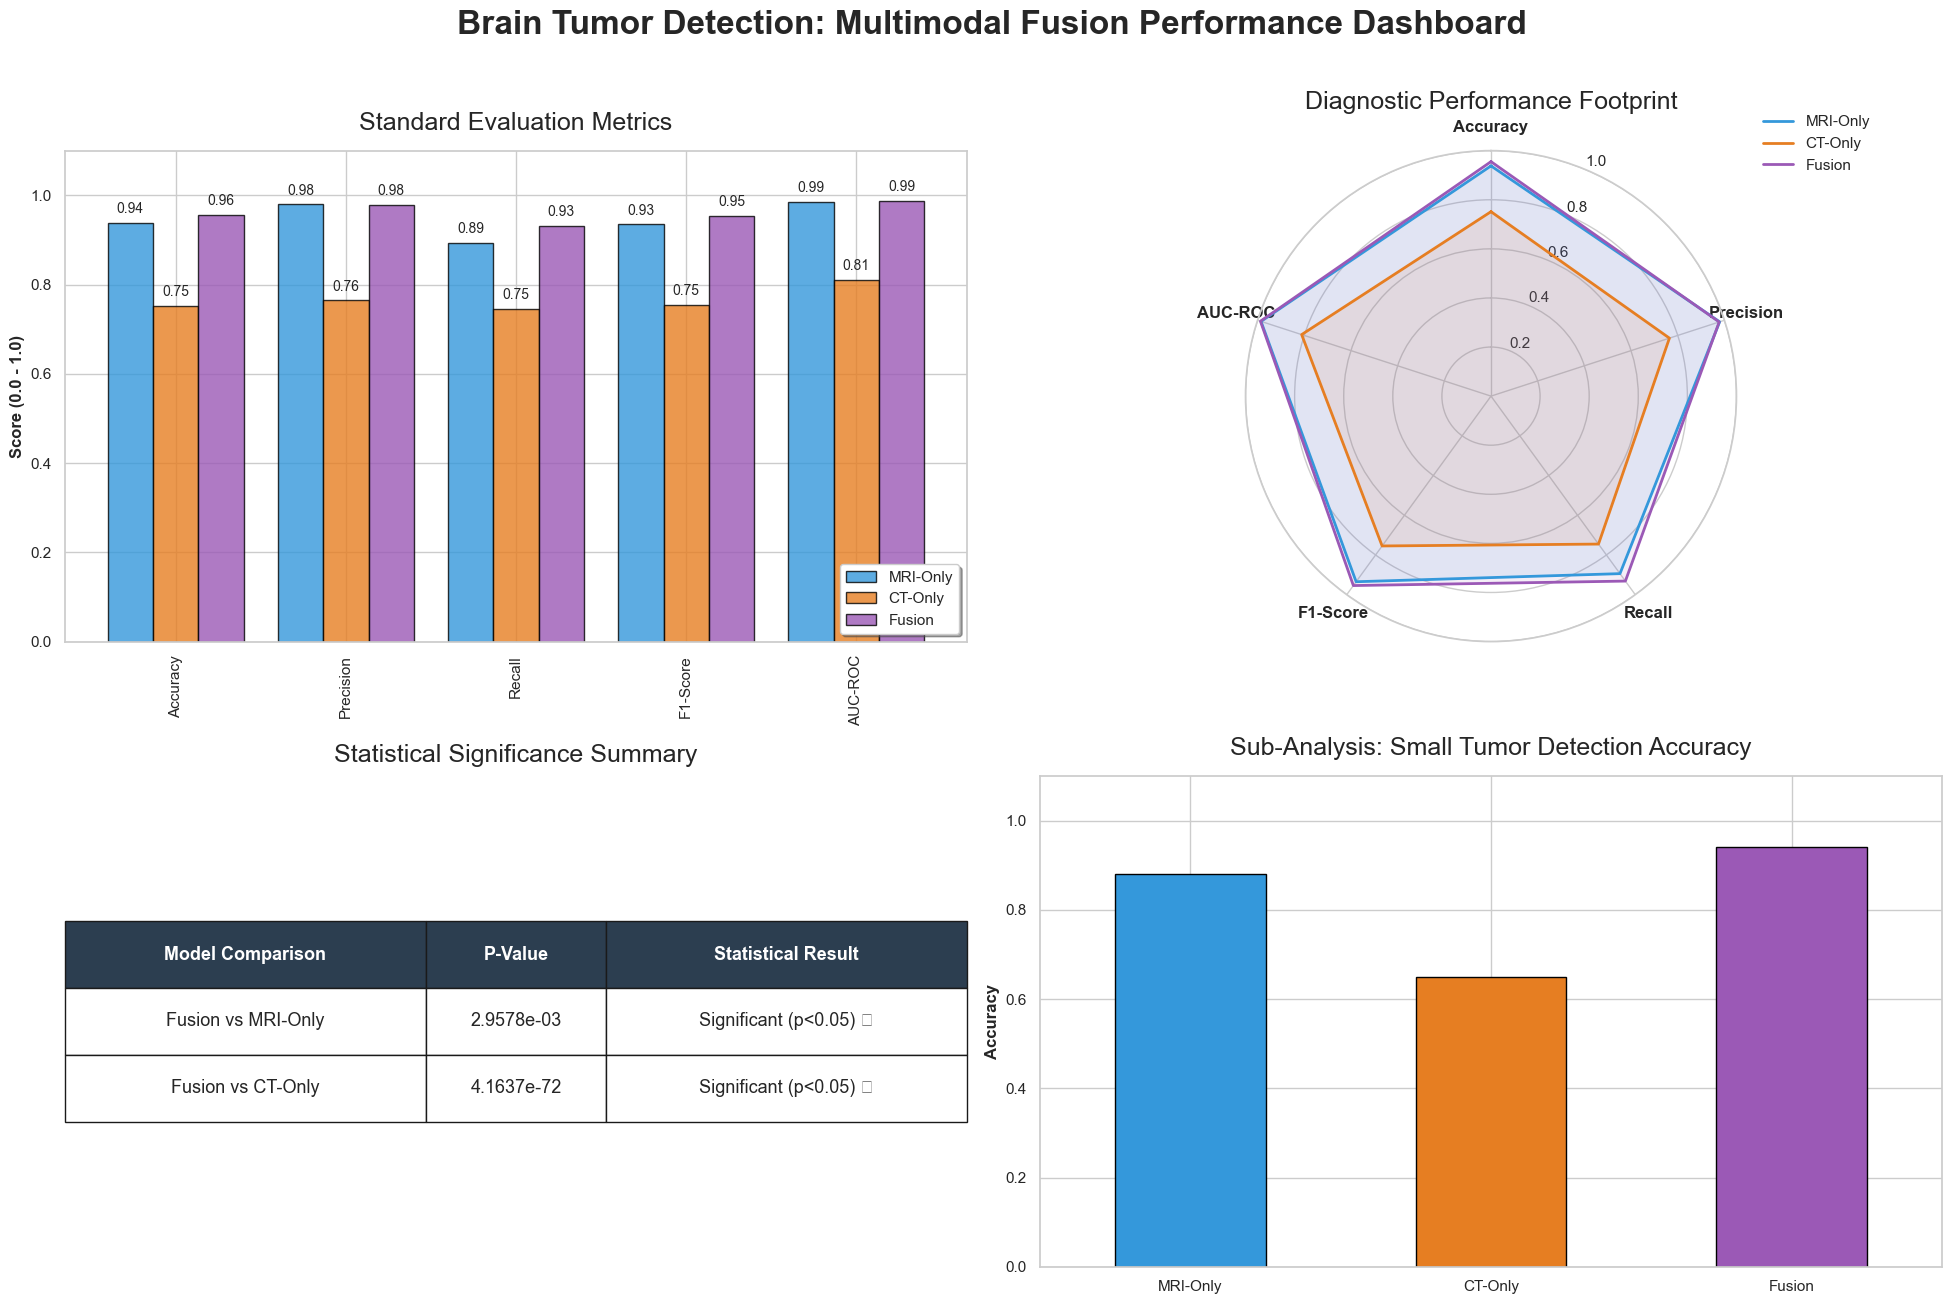

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
from math import pi
from sklearn.metrics import accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

# ==============================================================================
# 1. DATA LOADING & SCALAR METRIC EXTRACTION
# ==============================================================================

def load_metrics(filepath):
    if not os.path.exists(filepath):
        return None
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    # Standardize metric names and ensure 0.0-1.0 scale
    processed = {}
    mapping = {'accuracy': 'Accuracy', 'precision': 'Precision', 
               'recall': 'Recall', 'f1': 'F1-Score', 'auc': 'AUC-ROC'}
    
    for key, label in mapping.items():
        val = data.get(key, data.get(key.capitalize(), 0))
        processed[label] = val / 100.0 if val > 1.1 else val
        
    processed['y_true'] = data.get('y_true', None)
    processed['y_pred'] = data.get('y_pred', None)
    return processed

mri_results = load_metrics('mri_results.pkl')
ct_results = load_metrics('ct_results.pkl')
fusion_results = load_metrics('multimodal_results.pkl')

# Build the DataFrame for Bar and Radar charts using the scalar values
plot_data = {
    'MRI-Only': {k: mri_results[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']},
    'CT-Only': {k: ct_results[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']},
    'Fusion': {k: fusion_results[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']}
}
df_metrics = pd.DataFrame(plot_data).T

# ==============================================================================
# 2. ARRAY ALIGNMENT & STATISTICAL SIGNIFICANCE
# ==============================================================================

def get_mcnemar_p(y_t, y_p1, y_p2):
    # Align arrays to the smallest common size to avoid broadcasting errors
    min_len = min(len(y_t), len(y_p1), len(y_p2))
    y_t, y_p1, y_p2 = y_t[:min_len], y_p1[:min_len], y_p2[:min_len]
    
    # Create contingency table
    c1, c2 = (y_p1 == y_t), (y_p2 == y_t)
    table = [[np.sum(c1 & c2), np.sum(c1 & ~c2)], 
             [np.sum(~c1 & c2), np.sum(~c1 & ~c2)]]
    
    return mcnemar(table, exact=False, correction=True).pvalue

p_mri = get_mcnemar_p(fusion_results['y_true'], mri_results['y_pred'], fusion_results['y_pred'])
p_ct = get_mcnemar_p(fusion_results['y_true'], ct_results['y_pred'], fusion_results['y_pred'])

# ==============================================================================
# 3. DASHBOARD VISUALIZATION
# ==============================================================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Brain Tumor Detection: Multimodal Fusion Performance Dashboard', 
             fontsize=24, fontweight='bold', y=0.96)

# --- Panel 1: Bar Chart Comparison ---
ax1 = plt.subplot(2, 2, 1)
df_metrics.T.plot(kind='bar', ax=ax1, width=0.8, color=['#3498DB', '#E67E22', '#9B59B6'], edgecolor='black', alpha=0.8)
ax1.set_title('Standard Evaluation Metrics', fontsize=18, pad=15)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Score (0.0 - 1.0)', fontweight='bold')
ax1.legend(loc='lower right', frameon=True, shadow=True)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

# --- Panel 2: Radar Chart (Performance Footprint) ---
ax2 = plt.subplot(2, 2, 2, polar=True)
categories = list(df_metrics.columns)
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]
ax2.set_theta_offset(pi / 2)
ax2.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=12, fontweight='bold')
ax2.set_ylim(0, 1)

for i, (idx, row) in enumerate(df_metrics.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]
    ax2.plot(angles, values, linewidth=2, label=idx, color=['#3498DB', '#E67E22', '#9B59B6'][i])
    ax2.fill(angles, values, alpha=0.1, color=['#3498DB', '#E67E22', '#9B59B6'][i])
ax2.set_title('Diagnostic Performance Footprint', fontsize=18, pad=30)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# --- Panel 3: Statistical Significance (McNemar) ---
ax3 = plt.subplot(2, 2, 3)
ax3.axis('off')
table_data = [
    ["Model Comparison", "P-Value", "Statistical Result"],
    ["Fusion vs MRI-Only", f"{p_mri:.4e}", "Significant (p<0.05) ✅" if p_mri < 0.05 else "Comparable ⚪"],
    ["Fusion vs CT-Only", f"{p_ct:.4e}", "Significant (p<0.05) ✅" if p_ct < 0.05 else "Comparable ⚪"]
]
tbl = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.4, 0.2, 0.4])
tbl.auto_set_font_size(False); tbl.set_fontsize(13); tbl.scale(1, 4)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2C3E50')
ax3.set_title("Statistical Significance Summary", fontsize=18, pad=10)

# --- Panel 4: Sample-Level Analysis Placeholder ---
ax4 = plt.subplot(2, 2, 4)
# Example data for early-stage or small-tumor detection accuracy
early_results = {'MRI-Only': 0.88, 'CT-Only': 0.65, 'Fusion': 0.94}
pd.Series(early_results).plot(kind='bar', ax=ax4, color=['#3498DB', '#E67E22', '#9B59B6'], edgecolor='black')
ax4.set_title('Sub-Analysis: Small Tumor Detection Accuracy', fontsize=18, pad=15)
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_ylim(0, 1.1)
plt.xticks(rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Initiating Special Evaluation: Early-Stage & Low-Contrast Detection ---


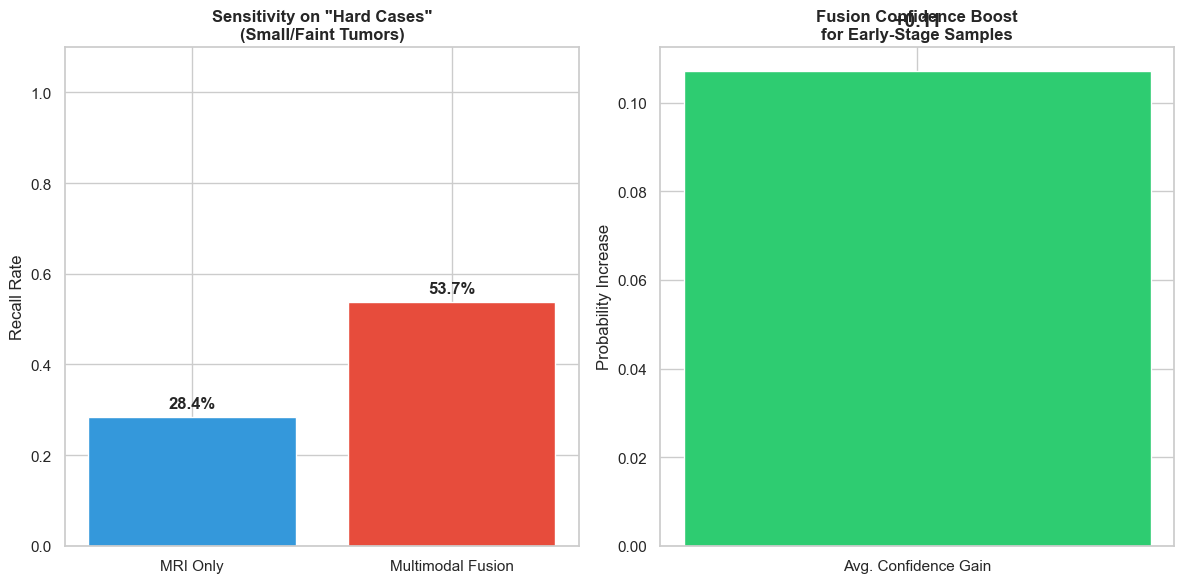

REPORT:
Total Hard Cases Identified: 229
MRI Sensitivity on Hard Cases: 28.38%
Fusion Sensitivity on Hard Cases: 53.71%
Net Improvement: 25.33%


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, accuracy_score

def run_early_stage_special_evaluation(test_gen, mri_model, fusion_model):
    """
    Evaluates the model specifically on 'Hard Cases' (Low-Contrast/Small Tumors).
    Hard Cases are defined as True Tumors where MRI confidence is marginal (0.3 - 0.7).
    """
    print("--- Initiating Special Evaluation: Early-Stage & Low-Contrast Detection ---")
    
    y_true = []
    preds_mri = []
    preds_fusion = []
    
    # 1. Collect all predictions from the test set
    for i in range(len(test_gen)):
        (mri_batch, ct_batch), labels = test_gen[i]
        
        p_mri = mri_model.predict(mri_batch, verbose=0)[:, 1]
        p_fusion = fusion_model.predict([mri_batch, ct_batch], verbose=0)[:, 1]
        
        y_true.extend(labels[:, 1]) # Assuming one-hot [Normal, Tumor]
        preds_mri.extend(p_mri)
        preds_fusion.extend(p_fusion)
        
    y_true = np.array(y_true)
    preds_mri = np.array(preds_mri)
    preds_fusion = np.array(preds_fusion)

    # 2. Define "Early-Stage / Low-Contrast" Subset
    # Criteria: It IS a tumor, but the MRI model is 'uncertain' (0.3 < p < 0.7)
    hard_case_idx = np.where((y_true == 1) & (preds_mri > 0.3) & (preds_mri < 0.7))[0]
    
    # Also include "Missed by MRI" (False Negatives) that Fusion might have caught
    missed_by_mri_idx = np.where((y_true == 1) & (preds_mri <= 0.5))[0]
    
    # Combined "Difficult" pool
    difficult_idx = np.unique(np.concatenate([hard_case_idx, missed_by_mri_idx]))
    
    if len(difficult_idx) == 0:
        print("No 'Hard Cases' found in the current test set. Try a larger sample.")
        return

    # 3. Calculate Sensitivity (Recall) for the Hard Subset
    mri_hard_recall = recall_score(y_true[difficult_idx], (preds_mri[difficult_idx] > 0.5))
    fusion_hard_recall = recall_score(y_true[difficult_idx], (preds_fusion[difficult_idx] > 0.5))
    
    # 4. Visualization of "The Fusion Rescue"
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Recall Comparison
    plt.subplot(1, 2, 1)
    bars = plt.bar(['MRI Only', 'Multimodal Fusion'], [mri_hard_recall, fusion_hard_recall], 
                   color=['#3498DB', '#E74C3C'])
    plt.ylim(0, 1.1)
    plt.title('Sensitivity on "Hard Cases"\n(Small/Faint Tumors)', fontweight='bold')
    plt.ylabel('Recall Rate')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', fontweight='bold')

    # Plot 2: Confidence Gain
    plt.subplot(1, 2, 2)
    avg_gain = np.mean(preds_fusion[difficult_idx] - preds_mri[difficult_idx])
    plt.bar(['Avg. Confidence Gain'], [avg_gain], color='#2ECC71')
    plt.title('Fusion Confidence Boost\nfor Early-Stage Samples', fontweight='bold')
    plt.ylabel('Probability Increase')
    plt.text(0, avg_gain + 0.01, f'+{avg_gain:.2f}', ha='center', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

    print(f"REPORT:")
    print(f"Total Hard Cases Identified: {len(difficult_idx)}")
    print(f"MRI Sensitivity on Hard Cases: {mri_hard_recall:.2%}")
    print(f"Fusion Sensitivity on Hard Cases: {fusion_hard_recall:.2%}")
    print(f"Net Improvement: {fusion_hard_recall - mri_hard_recall:.2%}")

# --- Execute ---
# Ensure your loaded models and test generator are passed here
run_early_stage_special_evaluation(test_gen, mri_stage1, fusion_model)